# Autonomous Research AI Agent using LangGraph

Nojood Alnahdi

**Tools Used**
- LangGraph
- LangChain
- Groq (LLM)
- Tavily Search

In [ ]:
!pip install -q langchain
!pip install -q langgraph
!pip install -q langchain-openai
!pip install -q langchain-community
!pip install -q chromadb
!pip install -q tavily-python
!pip install -q python-dotenv

In [ ]:
import langgraph
import langchain
import chromadb

print("Everything is working ")

Everything is working 


In [ ]:
!pip install -q langchain-groq

In [ ]:
#API KEY , initialize LLM
import os
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = "API_KEYS"

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [ ]:
#test LLM
response = llm.invoke(
    "Explain Agentic AI in one paragraph."
)

print(response.content)

Agentic AI refers to artificial intelligence systems that possess a degree of autonomy, self-awareness, and intentionality, enabling them to make decisions and act independently in pursuit of their goals. These AI systems are designed to perceive their environment, reason about their situation, and take actions to achieve their objectives, much like human agents. Agentic AI combines aspects of machine learning, cognitive architectures, and software agents to create systems that can learn, adapt, and interact with their surroundings in a proactive and purposeful manner. By endowing AI with agency, researchers aim to create more sophisticated and human-like intelligent systems that can operate effectively in complex, dynamic environments, and potentially lead to breakthroughs in areas such as robotics, healthcare, and finance.


**Adding tools for agent AI**

In [ ]:
!pip install -q tavily-python

In [ ]:
#API for the search tool
import os

os.environ["TAVILY_API_KEY"] = "API_KEYS"

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults #calling the tool

/tmp/ipykernel_26499/228311155.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults #calling the tool


In [ ]:
search = TavilySearchResults(max_results=5) #create search tool

/tmp/ipykernel_26499/2945252043.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search = TavilySearchResults(max_results=5) #create search tool


In [ ]:
results = search.invoke(
    "Latest trends in Agentic AI"
)

print(results) #test search

[{'title': 'Agentic AI News: Latest Trends & Tools in 2026', 'url': 'https://keepclaw.ai/agentic-ai-news', 'content': '## Latest Agentic AI News\n\nStay updated with the most recent developments in agentic AI and AI agents. We curate the most important AI agents news from around the industry.\n\nBreakthroughNew\n\nMarch 24, 2026\n\n### New AI Agents Can Autonomously Browse the Web and Complete Tasks\n\nAI agents are now capable of navigating websites, filling forms, and completing multi-step workflows without human input. This breakthrough in agentic AI is changing how businesses automate web-based operations. Major tech companies are integrating these capabilities into their enterprise solutions.\n\nProduct LaunchNew\n\nMarch 22, 2026\n\n### OpenAI Releases GPT-5 with Enhanced Agent Capabilities [...] Zero config deployment - Deploy AI agents instantly without infrastructure setup\n All AI models included - Access GPT-5, Claude 3.5, Gemini Pro, and more\n 24/7 agent uptime - Your agen

Analysis

In [ ]:
#search + LLM
query = "Latest trends in Agentic AI"

results = search.invoke(query)

prompt = f"""
You are a professional research analyst.

Research Question:
{query}

Search Results:
{results}

Write:
1. Summary
2. Key findings
3. Future trends
"""

In [ ]:
response = llm.invoke(prompt)

print(response.content)

**1. Summary**

The latest trends in Agentic AI indicate a significant shift towards autonomous decision-making and automation in various industries. Agentic AI refers to the use of artificial intelligence (AI) agents that can perform tasks autonomously, making decisions and taking actions without human intervention. The current trends suggest that Agentic AI is being adopted rapidly across North America, Europe, and Africa, with enterprises deploying specialized industry agents, multi-agent systems, and seamless integrations into CRM, ERP, and RPA platforms. The adoption is driven by measurable efficiency gains, natural language interfaces, and governance frameworks.

**2. Key Findings**

The key findings from the latest trends in Agentic AI are:

* **Autonomous workflow execution**: Agentic AI agents can now navigate websites, fill forms, and complete multi-step workflows without human input, transforming how businesses automate web-based operations.
* **Multi-agent collaboration**: 

**Define State**



In [ ]:
#state
from typing import TypedDict

class ResearchState(TypedDict):
    question: str
    search_results: list
    analysis: str
    report: str

In [ ]:
#testing the state
state = {
    "question": "Latest trends in Agentic AI",
    "search_results": [],
    "analysis": "",
    "report": ""
}

print(state)

{'question': 'Latest trends in Agentic AI', 'search_results': [], 'analysis': '', 'report': ''}


**building the nodes**

In [ ]:
#first node (search)
def search_node(state: ResearchState):
    query = state["question"]

    results = search.invoke(query)

    state["search_results"] = results

    return state

In [ ]:
#seconed node (analysis)
def analyze_node(state: ResearchState):

    prompt = f"""
    You are a professional research analyst.

    Research Question:
    {state["question"]}

    Search Results:
    {state["search_results"]}

    Write:
    1. Summary
    2. Key Findings
    3. Future Trends
    """

    response = llm.invoke(prompt)

    state["analysis"] = response.content

    return state

testing nodes

In [ ]:
state = {
    "question": "Latest trends in Agentic AI",
    "search_results": [],
    "analysis": "",
    "report": ""
}

state = search_node(state)

print(len(state["search_results"]))

5


In [ ]:
state = analyze_node(state)

print(state["analysis"])

**Summary**

The latest trends in Agentic AI indicate a significant shift towards autonomous decision-making and automation. Agentic AI is transforming industries by enabling AI agents to handle complex tasks, make decisions, and interact with humans seamlessly. The technology is being adopted across various sectors, including customer service, healthcare, finance, and research. Key trends include the integration of AI agents into core enterprise platforms, the use of natural language interfaces, and the development of multi-agent systems. As Agentic AI continues to evolve, it is expected to drive significant efficiency gains, improve decision-making, and enhance customer experiences.

**Key Findings**

1. **Autonomous Decision-Making**: Agentic AI is enabling AI agents to make decisions autonomously, transforming traditional SaaS workflows and customer service operations.
2. **Multi-Agent Systems**: Multiple AI agents are working together to solve complex problems, leading to more eff

**Building LangGraph**

In [ ]:
from langgraph.graph import StateGraph, START, END

In [ ]:
graph = StateGraph(ResearchState) #create graph

In [ ]:
#add nodes
graph.add_node("search", search_node)

graph.add_node("analyze", analyze_node)

In [ ]:
# connect nodes
graph.add_edge(START, "search")

graph.add_edge("search", "analyze")

graph.add_edge("analyze", END)

In [ ]:
#compile
app = graph.compile()

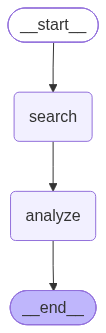

In [ ]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

In [ ]:
#agent
state = {
    "question": "Latest trends in Agentic AI",
    "search_results": [],
    "analysis": "",
    "report": ""
}

result = app.invoke(state)

In [ ]:
print(result["analysis"])

**Summary**

The latest trends in Agentic AI indicate a significant shift towards autonomous decision-making and automation. Agentic AI is transforming industries by enabling AI agents to handle complex tasks, make decisions, and interact with humans seamlessly. The technology is being adopted across various sectors, including customer service, healthcare, finance, and research. Key trends include the integration of AI agents into core enterprise platforms, the use of natural language interfaces, and the development of multi-agent systems. As Agentic AI continues to evolve, it is expected to drive significant efficiency gains, improve decision-making, and enhance customer experiences.

**Key Findings**

1. **Autonomous Decision-Making**: Agentic AI is enabling AI agents to make decisions autonomously, transforming traditional SaaS tools and workflows.
2. **Multi-Agent Collaboration**: Multiple AI agents are working together to solve complex problems, specializing in different tasks and